# CS 5864 Homework 4, Part 1: Generative Adversarial Networks

In [1]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

%load_ext autoreload
%autoreload 2

In [ ]:
from gan.train import train

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "gpu")

# GAN loss functions

You'll need to implement three different loss functions. The first is the loss from the [original GAN paper](https://arxiv.org/pdf/1406.2661.pdf) (note we use NSGAN). The next is the loss from [LS-GAN](https://arxiv.org/abs/1611.04076), and finally you'll implement the loss from the [Wasserstein GAN (WGAN)](https://arxiv.org/abs/1701.07875) and impose [spectral normalization](https://arxiv.org/pdf/1802.05957).


### GAN loss

**TODO:** You need to implement the `discriminator_loss` and `generator_loss` functions in `gan/losses.py`.

The generator loss is given by:
$$\ell_G  =  -\mathbb{E}_{z \sim p(z)}\left[\log D(G(z))\right]$$
and the discriminator loss is:
$$ \ell_D = -\mathbb{E}_{x \sim p_\text{data}}\left[\log D(x)\right] - \mathbb{E}_{z \sim p(z)}\left[\log \left(1-D(G(z))\right)\right]$$

Note that these equations are negated because we will be *minimizing* these losses.

**HINTS**: Use the `torch.nn.functional.binary_cross_entropy_with_logits` function to compute the binary cross entropy loss since it is more numerically stable than using a softmax followed by BCE loss.

We will be averaging over the elements of the minibatch instead of computing the expectation of $\log D(G(z))$, $\log D(x)$ and $\log \left(1-D(G(z))\right)$.

In [4]:
from gan.losses import discriminator_loss, generator_loss

### Least Squares GAN loss

**TODO:** You need to implement the `ls_discriminator_loss` and `ls_generator_loss` functions in `gan/losses.py`.

[Least Squares GAN](https://arxiv.org/abs/1611.04076) is an alernative to the original GAN loss function. 
For this part, all you need to do change the loss function and retrain the model. 

Specifically, you'll implement equation (9) in the paper:
$$\ell_G  =  \frac{1}{2}\mathbb{E}_{z \sim p(z)}\left[\left(D(G(z))-1\right)^2\right]$$
and the discriminator loss:
$$ \ell_D = \frac{1}{2}\mathbb{E}_{x \sim p_\text{data}}\left[\left(D(x)-1\right)^2\right] + \frac{1}{2}\mathbb{E}_{z \sim p(z)}\left[ \left(D(G(z))\right)^2\right]$$

In [ ]:
from gan.losses import ls_discriminator_loss, ls_generator_loss

### Wasserstein GAN (WGAN) loss

**TODO:** You need to implement the `wgan_discriminator_loss` and `wgan_generator_loss`
functions in `gan/losses.py`.

In WGAN, the discriminator is replaced by a **critic** that outputs an unconstrained
(real-valued) score instead of a probability. We do **not** apply a sigmoid to the
output of the critic, and we do **not** use binary cross-entropy. Instead, we directly
optimize a surrogate for the Wasserstein distance.

The generator loss is:
$$
\ell_G = -\mathbb{E}_{z \sim p(z)}\left[ D(G(z)) \right]
$$

and the critic (discriminator) loss is:
$$
\ell_D = \mathbb{E}_{z \sim p(z)}\left[ D(G(z)) \right]
        - \mathbb{E}_{x \sim p_\text{data}}\left[ D(x) \right]
$$

Remember that we are minimizing these losses, so maximizing
$\mathbb{E}[D(x)] - \mathbb{E}[D(G(z))]$ is equivalent to minimizing the expression
above. As before, we will approximate the expectations using minibatch averages.

For WGAN in this assignment, you will enforce the 1-Lipschitz constraint on the critic
using **spectral normalization** (instead of weight clipping or a gradient penalty).


In [ ]:
from gan.losses import wgan_discriminator_loss, wgan_generator_loss

# GAN model architecture

**TODO:** Next, you'll need to implement the `Discriminator` and `Generator` networks in `gan/models.py`.

We'll be using the architecture from [DCGAN](https://arxiv.org/pdf/1511.06434.pdf):

**Discriminator:**

- convolutional layer with in_channels=3, out_channels=128, kernel=4, stride=2
- convolutional layer with in_channels=128, out_channels=256, kernel=4, stride=2
- batch norm
- convolutional layer with in_channels=256, out_channels=512, kernel=4, stride=2
- batch norm
- convolutional layer with in_channels=512, out_channels=1024, kernel=4, stride=2
- batch norm
- convolutional layer with in_channels=1024, out_channels=1, kernel=4, stride=1

Use padding = 1 (not 0) for all the convolutional layers.

You can either use LeakyReLu throughout the discriminator (and a negative slope value of 0.2) or just use relu.

The discriminator will output a single score for each sample.The output of your discriminator should be a single value score corresponding to each input sample.


**Generator:**

**Note:** Here, you'll need to use transposed convolution (sometimes known as fractionally-strided convolution). This function is implemented in pytorch as `torch.nn.ConvTranspose2d`.

- transpose convolution with in_channels=NOISE_DIM, out_channels=1024, kernel=4, stride=1
- batch norm
- transpose convolution with in_channels=1024, out_channels=512, kernel=4, stride=2
- batch norm
- transpose convolution with in_channels=512, out_channels=256, kernel=4, stride=2
- batch norm
- transpose convolution with in_channels=256, out_channels=128, kernel=4, stride=2
- batch norm
- transpose convolution with in_channels=128, out_channels=3, kernel=4, stride=2

The generator network will need to map the output values between -1 and 1 using a `tanh` nonlinearity. The output should be of size 64x64 with 3 channels for each sample (equal dimensions to the images from the dataset).

**Spectral normalization for WGAN:**

For the WGAN part of the assignment, you should modify your `Discriminator` in `gan/models.py` to use **spectral normalization** on each convolutional layer. You can use `torch.nn.utils.spectral_norm` to wrap your `nn.Conv2d` layers.

One convenient approach is to add a `use_spectral_norm` flag to the `Discriminator` constructor and apply spectral normalization only when this flag is `True`. For the vanilla GAN (NSGAN) and LS-GAN experiments you should use the same architecture *without* spectral normalization, and for WGAN you should enable spectral normalization in the discriminator.


In [ ]:
from gan.models import Discriminator, Generator

# Data loading

Our dataset is pretty small, so in order to prevent overfitting, we need to perform data augmentation.

**TODO:** You'll need to implement some data augmentation by adding new transforms to the cell below. 

The easiest you can do is just use the RandomCrop and ColorJitter, but feel free to play around with other augmentations as well to see how it affects the performance of your model. See https://pytorch.org/vision/stable/transforms.html.

In [8]:
batch_size = 32
imsize = 64
cat_root = './cats'

cat_train = ImageFolder(root=cat_root, transform=transforms.Compose([
  transforms.ToTensor(),
    
    ## Use some some augmentations here
    
]))

cat_loader_train = DataLoader(cat_train, batch_size=batch_size, drop_last=True)

### Visualize dataset

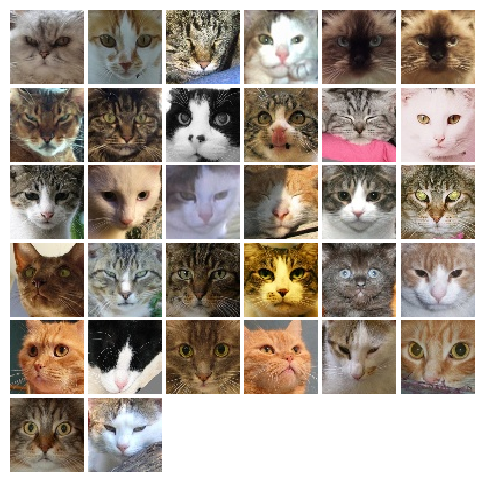

In [9]:
from gan.utils import show_images

# imgs = cat_loader_train.__iter__().next()[0].numpy().squeeze()
imgs = next(iter(cat_loader_train))[0].numpy().squeeze()
show_images(imgs, color=True)

# Training 


**TODO:** You need to write the training loop in `gan/train.py`.

In [10]:
NOISE_DIM = 100
NUM_EPOCHS = 50
learning_rate = 0.001

### Train GAN

In [11]:
D = Discriminator().to(device)
G = Generator(noise_dim=NOISE_DIM).to(device)

In [12]:
D_optimizer = torch.optim.Adam(D.parameters(), lr=learning_rate, betas = (0.5, 0.999))
G_optimizer = torch.optim.Adam(G.parameters(), lr=learning_rate, betas = (0.5, 0.999))

In [ ]:
# NSGAN
train(D, G, D_optimizer, G_optimizer, discriminator_loss, 
          generator_loss, num_epochs=NUM_EPOCHS, show_every=250,
          batch_size=batch_size, train_loader=cat_loader_train, device=device)


### Train LS-GAN

In [14]:
D = Discriminator().to(device)
G = Generator(noise_dim=NOISE_DIM).to(device)

In [15]:
D_optimizer = torch.optim.Adam(D.parameters(), lr=learning_rate, betas = (0.5, 0.999))
G_optimizer = torch.optim.Adam(G.parameters(), lr=learning_rate, betas = (0.5, 0.999))

In [ ]:
# ls-gan
train(D, G, D_optimizer, G_optimizer, ls_discriminator_loss, 
          ls_generator_loss, num_epochs=NUM_EPOCHS, show_every=250,
          batch_size=batch_size, train_loader=cat_loader_train, device=device)

### Train WGAN

In [11]:
# for WGAN we turn on spectral normalization in the discriminator
D = Discriminator(use_spectral_norm=True).to(device)
G = Generator(noise_dim=NOISE_DIM).to(device)

In [12]:
D_optimizer = torch.optim.Adam(D.parameters(), lr=learning_rate, betas = (0.5, 0.999))
G_optimizer = torch.optim.Adam(G.parameters(), lr=learning_rate, betas = (0.5, 0.999))

In [ ]:
# WGAN with spectral normalization
train(D, G, D_optimizer, G_optimizer, wgan_discriminator_loss,
      wgan_generator_loss, num_epochs=NUM_EPOCHS, show_every=250,
      batch_size=batch_size, train_loader=cat_loader_train, device=device)

### Analysis

Briefly compare the behavior and visual quality of the three GAN variants you trained: the standard (non-saturating) GAN, the Least Squares GAN (LS-GAN), and the Wasserstein GAN (WGAN) with spectral normalization. You might address questions like, How stable was training for each objective? How quickly did each model start generating plausible cat images? How do the final sample qualities compare across the three methods? Any differences you notice in convergence behavior, mode collapse, or artifacts in the generated images.

## Standard GAN
Standard GAN trains unstable and starts to generate plausible images quickier than LS-GAN and WGAN, but the image quality is weak. It converges fast at first, but often collapse or have noises. The final sample quality is moderate across the three methods.

## LS-GAN
LS-GAN trains most stable and has less collapse across three models. It generates plausible images at moderate speed and provides smoother convergene. The final image quality is best across three methods.

## WGAN
WGAN trains unstable and generates plausible images at lowest speed compared to other 2 methods. The final quality is the worst. It converges at the lowest speed and often collapses. 